# Confidence Threshold and Uncertain Rejection

## Facial Emotion Recognition on FER2013

This notebook documents the confidence-threshold stage of the project.

The goal is to reduce unreliable predictions by allowing the model to reject low-confidence outputs.

Instead of always forcing the model to predict one of the seven FER2013 emotion classes, we introduce an additional decision state:

## Uncertain

This is not a new trained emotion class. It is a post-processing rejection decision.

### Why this matters

In real-time facial emotion recognition, forcing a prediction when the model is uncertain can produce misleading results. A threshold-based rejection mechanism makes the system more reliable by only accepting predictions when the model confidence is high enough.

### Main idea

For each prediction:

1. Compute the softmax probabilities.
2. Find the highest probability.
3. If the highest probability is below the selected threshold, output `Uncertain`.
4. Otherwise, output the predicted emotion.


## 1. Import Required Libraries

This notebook reads previously generated threshold analysis files and demo figures.

It does not retrain any model.


In [1]:
from pathlib import Path
import json

from IPython.display import Image, display
import pandas as pd

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Detect Project Paths

The following cell works whether the notebook is launched from the project root directory or from the `notebooks/` directory.


In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
DEMO_DIR = PROJECT_ROOT / "outputs" / "demo"

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Metrics directory: {METRICS_DIR}")
print(f"Demo directory: {DEMO_DIR}")

Project root: d:\projects\facial-emotion-recognition
Figures directory: d:\projects\facial-emotion-recognition\outputs\figures
Metrics directory: d:\projects\facial-emotion-recognition\outputs\metrics
Demo directory: d:\projects\facial-emotion-recognition\outputs\demo


## 3. Required Files Check

Before analyzing threshold behavior, we verify that all required files exist.


In [3]:
required_files = {
    "Threshold analysis CSV": METRICS_DIR / "threshold_analysis_validation.csv",
    "Threshold analysis JSON": METRICS_DIR / "threshold_analysis_validation.json",
    "Recommended threshold": METRICS_DIR / "recommended_threshold.json",
    "Threshold analysis chart": FIGURES_DIR / "threshold_analysis_validation.png",
    "Threshold demo figure": FIGURES_DIR / "threshold_demo_test_predictions.png",
    "Threshold demo figure copy": DEMO_DIR / "threshold_demo_test_predictions.png",
}

file_check = pd.DataFrame(
    {
        "File": list(required_files.keys()),
        "Path": [str(path) for path in required_files.values()],
        "Exists": [path.exists() for path in required_files.values()],
    }
)

display(file_check)

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    print("Missing files:")
    for item in missing_files:
        print(f"- {item}")
    raise FileNotFoundError(
        "Some threshold output files are missing. "
        "Run scripts.threshold_analysis and scripts.demo_test_predictions first."
    )
else:
    print("All required threshold files are available.")

,File,Path,Exists
0,Threshold analysis CSV,d:\projects\facial-emotion-recognition\outputs...,True
1,Threshold analysis JSON,d:\projects\facial-emotion-recognition\outputs...,True
2,Recommended threshold,d:\projects\facial-emotion-recognition\outputs...,True
3,Threshold analysis chart,d:\projects\facial-emotion-recognition\outputs...,True
4,Threshold demo figure,d:\projects\facial-emotion-recognition\outputs...,True
5,Threshold demo figure copy,d:\projects\facial-emotion-recognition\outputs...,True


All required threshold files are available.


## 4. Thresholding Concept

The trained model outputs seven softmax probabilities:

| Class | Emotion |
|---:|---|
| 0 | Angry |
| 1 | Disgust |
| 2 | Fear |
| 3 | Happy |
| 4 | Sad |
| 5 | Surprise |
| 6 | Neutral |

Without thresholding, the model always chooses the class with the highest probability.

With thresholding, the system first checks the confidence:

```text
if max_probability < threshold:
    output = "Uncertain"
else:
    output = predicted_emotion
```

This makes the system more cautious.


## 5. Important Note About Neutral vs Uncertain

FER2013 already contains a real `Neutral` class.

Therefore, `Neutral` and `Uncertain` should not be treated as the same thing.

| Label | Meaning |
|---|---|
| Neutral | The model predicts a neutral facial expression. |
| Uncertain | The model does not have enough confidence to make a reliable prediction. |

This distinction makes the project more scientifically correct.

If a project requirement says "neutral rejection class", it can be explained as a rejection mechanism. However, in implementation, `Uncertain` is clearer and avoids confusing a real emotion class with a confidence failure.


## 6. Load Threshold Analysis Results

The threshold analysis was performed on the validation set using the selected model:

## Improved CNN without Class Weights

This model was selected because it achieved the best test accuracy and weighted F1-score.


In [4]:
threshold_results_path = METRICS_DIR / "threshold_analysis_validation.csv"

threshold_results = pd.read_csv(threshold_results_path)

display(threshold_results)

rounded_threshold_results = threshold_results.copy()

numeric_columns = [
    "threshold",
    "coverage",
    "rejection_rate",
    "accepted_accuracy",
    "raw_accuracy",
]

rounded_threshold_results[numeric_columns] = rounded_threshold_results[numeric_columns].round(4)

display(rounded_threshold_results)

,threshold,total_samples,accepted_samples,rejected_samples,coverage,rejection_rate,accepted_accuracy,raw_accuracy
0,0.40,3589,2438,1151,0.679298,0.320702,0.694422,0.594037
1,0.45,3589,2064,1525,0.575091,0.424909,0.732558,0.594037
2,0.50,3589,1784,1805,0.497074,0.502926,0.770179,0.594037
3,0.55,3589,1549,2040,0.431597,0.568403,0.814719,0.594037
4,0.60,3589,1358,2231,0.378378,0.621622,0.847570,0.594037
5,0.65,3589,1220,2369,0.339928,0.660072,0.871311,0.594037
6,0.70,3589,1088,2501,0.303149,0.696851,0.890625,0.594037
7,0.75,3589,948,2641,0.264140,0.735860,0.914557,0.594037
8,0.80,3589,825,2764,0.229869,0.770131,0.933333,0.594037
9,0.85,3589,701,2888,0.195319,0.804681,0.952924,0.594037


,threshold,total_samples,accepted_samples,rejected_samples,coverage,rejection_rate,accepted_accuracy,raw_accuracy
0,0.40,3589,2438,1151,0.6793,0.3207,0.6944,0.594
1,0.45,3589,2064,1525,0.5751,0.4249,0.7326,0.594
2,0.50,3589,1784,1805,0.4971,0.5029,0.7702,0.594
3,0.55,3589,1549,2040,0.4316,0.5684,0.8147,0.594
4,0.60,3589,1358,2231,0.3784,0.6216,0.8476,0.594
5,0.65,3589,1220,2369,0.3399,0.6601,0.8713,0.594
6,0.70,3589,1088,2501,0.3031,0.6969,0.8906,0.594
7,0.75,3589,948,2641,0.2641,0.7359,0.9146,0.594
8,0.80,3589,825,2764,0.2299,0.7701,0.9333,0.594
9,0.85,3589,701,2888,0.1953,0.8047,0.9529,0.594


## 7. Threshold Metrics Explained

The threshold analysis uses the following metrics:

| Metric | Meaning |
|---|---|
| Raw Accuracy | Accuracy before applying threshold rejection |
| Accepted Accuracy | Accuracy only on predictions that were not rejected |
| Coverage | Percentage of samples accepted by the threshold |
| Rejection Rate | Percentage of samples rejected as `Uncertain` |

A higher threshold usually increases accepted accuracy, but decreases coverage.


## 8. Threshold Analysis Chart

The chart below shows the trade-off between accepted accuracy, coverage, and rejection rate.


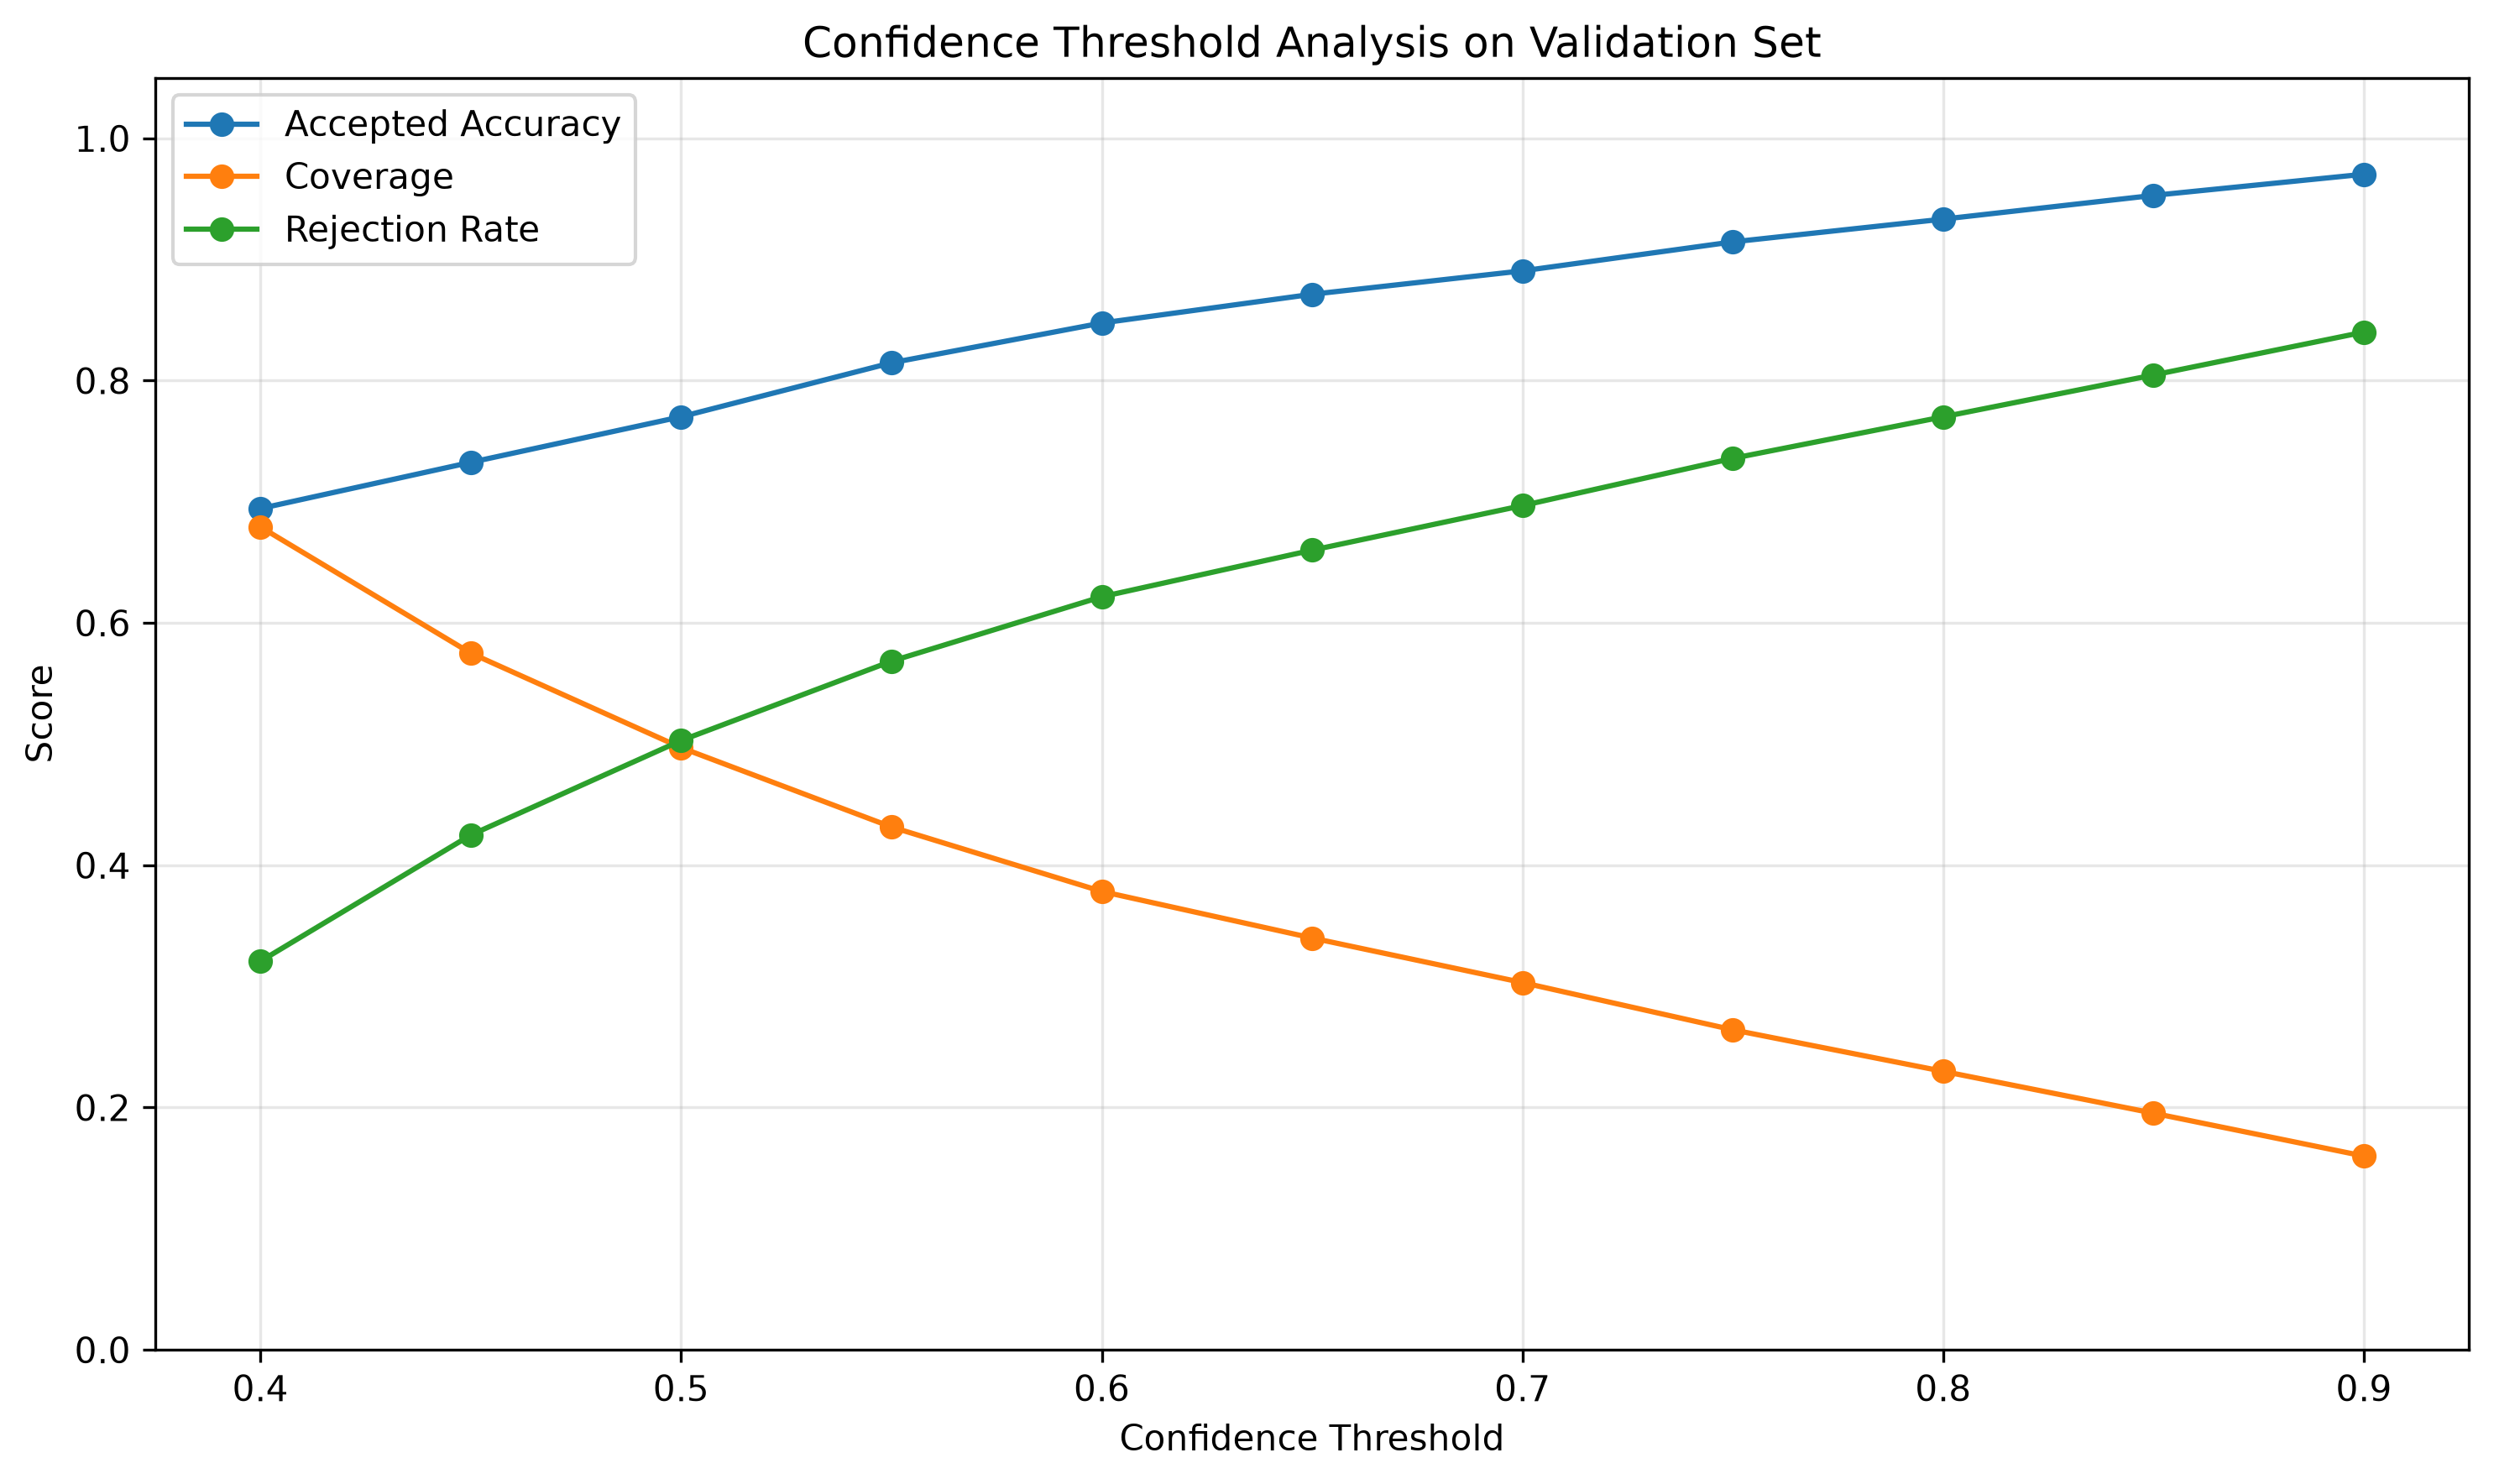

In [5]:
display(Image(filename=str(FIGURES_DIR / "threshold_analysis_validation.png")))

## 9. Recommended Threshold

The recommended threshold was selected using practical constraints:

1. Accepted accuracy should be at least 80%.
2. Coverage should be at least 40%.
3. Among valid thresholds, choose the highest-coverage option.

This avoids selecting an overly strict threshold such as 0.90, which gives very high accepted accuracy but rejects too many samples.


In [6]:
recommended_path = METRICS_DIR / "recommended_threshold.json"

with recommended_path.open("r", encoding="utf-8") as file:
    recommended_threshold = json.load(file)

recommended_table = pd.DataFrame(
    {
        "Metric": list(recommended_threshold.keys()),
        "Value": list(recommended_threshold.values()),
    }
)

display(recommended_table)

,Metric,Value
0,recommended_threshold,0.55
1,accepted_accuracy,0.814719
2,coverage,0.431597
3,rejection_rate,0.568403
4,raw_accuracy,0.594037
5,minimum_accepted_accuracy_rule,0.8
6,minimum_coverage_rule,0.4
7,selection_note,Selected highest-coverage threshold satisfying...


## 10. Practical Interpretation

The selected threshold is:

## 0.55

At this threshold:

- Raw validation accuracy is approximately 59.4%.
- Accepted accuracy increases to approximately 81.5%.
- Coverage is approximately 43.2%.
- Rejection rate is approximately 56.8%.

This means the model becomes much more reliable when it accepts a prediction, but it rejects many uncertain cases.

This behavior is useful for real-time applications because it avoids displaying a confident-looking label when the model is actually unsure.


In [7]:
selected_row = threshold_results[
    threshold_results["threshold"] == recommended_threshold["recommended_threshold"]
]

display(selected_row)

,threshold,total_samples,accepted_samples,rejected_samples,coverage,rejection_rate,accepted_accuracy,raw_accuracy
3,0.55,3589,1549,2040,0.431597,0.568403,0.814719,0.594037


## 11. Trade-Off Analysis

The table below highlights several possible thresholds.

Lower thresholds accept more predictions but include more mistakes.

Higher thresholds accept fewer predictions but are more accurate when they do accept.


In [8]:
selected_thresholds = threshold_results[
    threshold_results["threshold"].isin([0.40, 0.50, 0.55, 0.60, 0.70, 0.80, 0.90])
].copy()

selected_thresholds[numeric_columns] = selected_thresholds[numeric_columns].round(4)

display(selected_thresholds)

,threshold,total_samples,accepted_samples,rejected_samples,coverage,rejection_rate,accepted_accuracy,raw_accuracy
0,0.40,3589,2438,1151,0.6793,0.3207,0.6944,0.594
2,0.50,3589,1784,1805,0.4971,0.5029,0.7702,0.594
3,0.55,3589,1549,2040,0.4316,0.5684,0.8147,0.594
4,0.60,3589,1358,2231,0.3784,0.6216,0.8476,0.594
6,0.70,3589,1088,2501,0.3031,0.6969,0.8906,0.594
8,0.80,3589,825,2764,0.2299,0.7701,0.9333,0.594
10,0.90,3589,574,3015,0.1599,0.8401,0.9704,0.594


## 12. Why 0.55 Was Selected

Threshold 0.55 is a practical compromise.

| Threshold | Behavior |
|---:|---|
| 0.40 | Accepts more samples, but accepted accuracy is below 70%. |
| 0.55 | Achieves above 80% accepted accuracy while keeping above 40% coverage. |
| 0.90 | Very high accepted accuracy, but rejects about 84% of samples. |

For a real-time webcam demo, a threshold that rejects too many predictions can make the system feel inactive.

Therefore, 0.55 is more useful than 0.90 for this project.


## 13. Demo Predictions with Threshold

The figure below shows test-set examples after applying the recommended threshold.

Each image includes:

- True label
- Predicted label
- Confidence
- Whether the prediction was accepted or rejected
- Top-3 predicted emotions


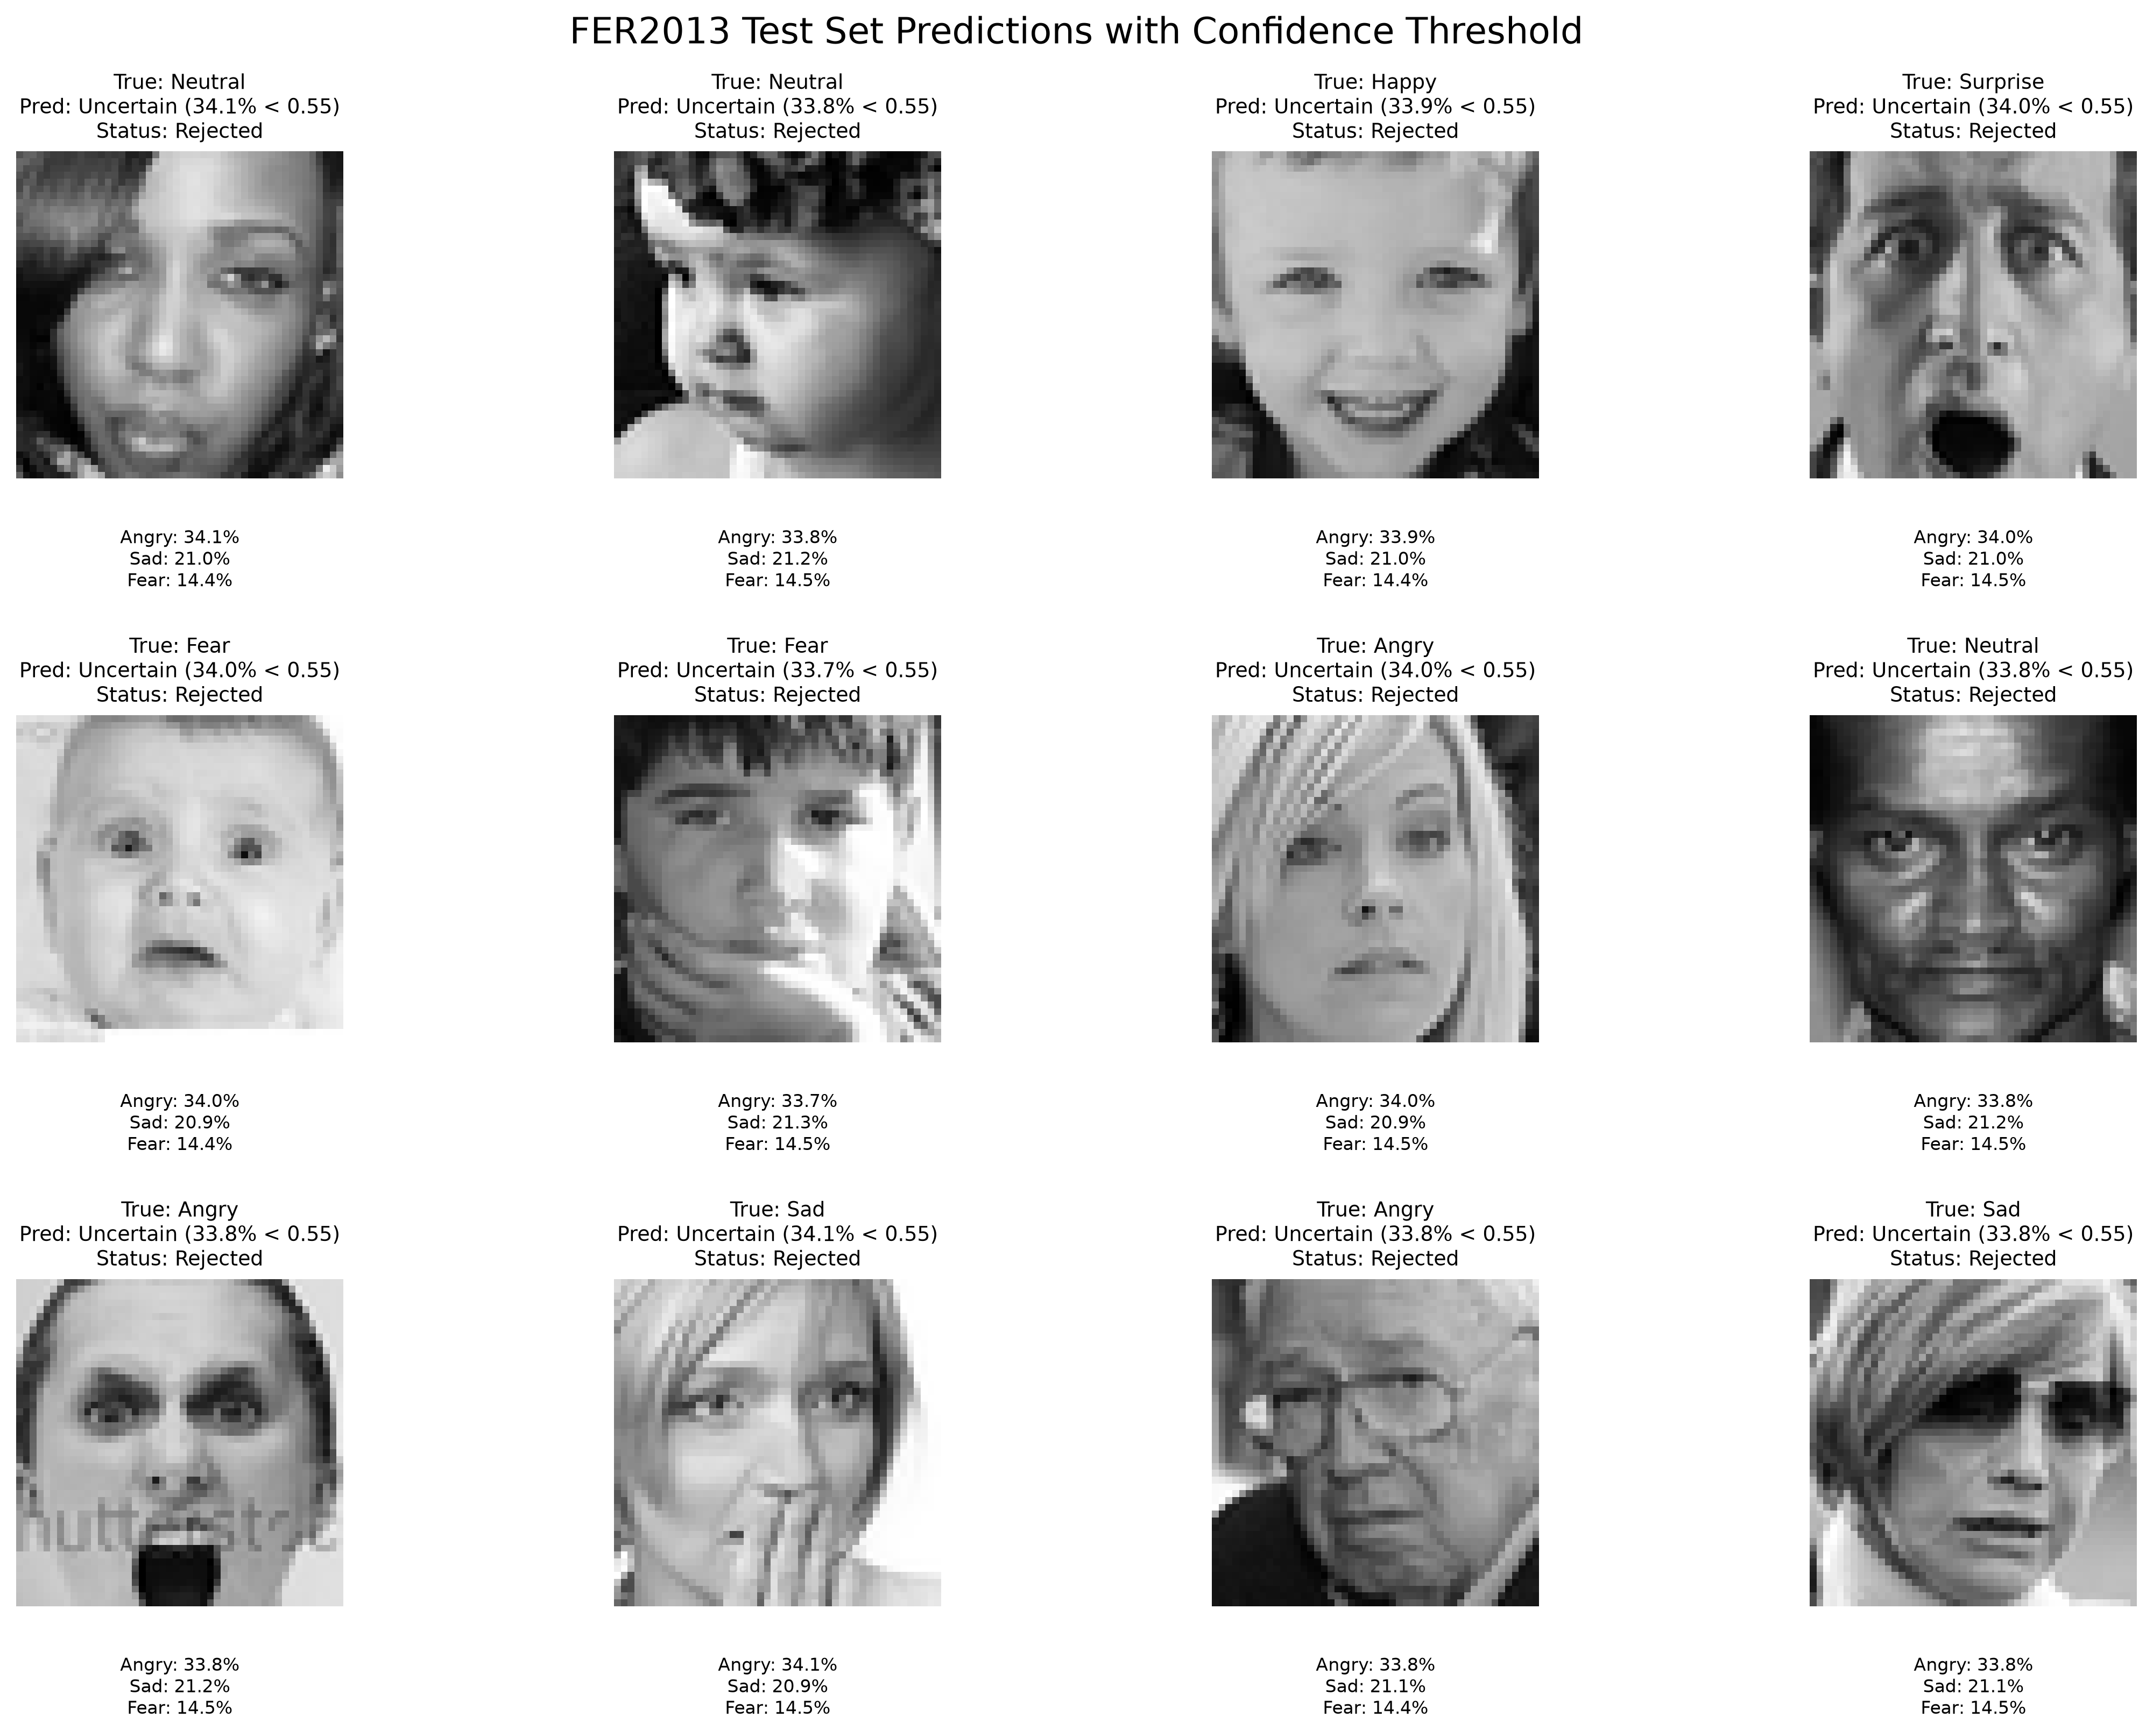

In [9]:
display(Image(filename=str(FIGURES_DIR / "threshold_demo_test_predictions.png")))

## 14. Summary of the Threshold Stage

This stage completes the extra requirement of the project.

The system can now:

1. Load the selected trained model.
2. Predict probabilities for a face image.
3. Apply a confidence threshold.
4. Return a normal emotion label if confidence is high enough.
5. Return `Uncertain` if confidence is too low.
6. Display top-3 predictions for better interpretability.

### Key result

Using a threshold of 0.55 increased accepted validation accuracy from about 59.4% to about 81.5% on accepted predictions.

This does not mean the model becomes 81.5% accurate on all samples. It means the model becomes more reliable when it chooses not to reject.


## 15. Limitations

Thresholding improves reliability, but it has limitations:

1. It does not improve the underlying model itself.
2. It rejects many samples.
3. It may reject difficult but important cases.
4. It does not solve class imbalance.
5. It does not fix weak performance on classes such as `Disgust`.

Thresholding should be presented as a reliability layer, not as a replacement for better training data or a stronger model.


## 16. Next Step

The next stage is to implement real-time webcam inference.

The webcam system should include:

1. Face detection
2. Face crop preprocessing
3. Model prediction
4. Confidence thresholding
5. `Uncertain` output for low-confidence cases
6. Top-3 predictions
7. FPS display
8. Optional screenshot saving

This will turn the trained model into a live facial emotion recognition demo.
